In [2]:
import requests
import pandas as pd
from datetime import datetime, timezone

# ==========================================
# CONFIGURATION
# ==========================================
API_KEY = "85dcaa01bffe93cb35d2620eaccbc268"
CITIES = ["London", "New York", "Tokyo", "Nairobi", "Paris"]
BASE_URL = "http://api.openweathermap.org/data/2.5/weather"

# ==========================================
# TASK 1: EXTRACT DATA
# ==========================================
raw_data = []

print("--- Starting Data Extraction ---")
for city in CITIES:
    url = f"{BASE_URL}?q={city}&appid={API_KEY}&units=metric"
    try:
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            raw_data.append(response.json())
            print(f"✅ Successfully extracted data for: {city}")
        else:
            print(f"❌ Failed to retrieve data for {city}. Status code: {response.status_code}")
    except requests.exceptions.RequestException as e:
        print(f"⚠️ Connection error for {city}: {e}")

# ==========================================
# TASK 2: TRANSFORM DATA
# ==========================================
if raw_data:
    print("\n--- Starting Data Transformation ---")
    processed_list = []
    
    for item in raw_data:
        city_name = item.get("name")
        temp = item["main"].get("temp")
        humidity = item["main"].get("humidity")
        weather_condition = item["weather"][0].get("description")
        wind_speed = item["wind"].get("speed")
        timestamp = item.get("dt")
        recorded_at = datetime.fromtimestamp(timestamp, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S')
        
        processed_list.append({
            "City": city_name,
            "Temperature_C": temp,
            "Humidity_Percent": humidity,
            "Weather_Condition": weather_condition.capitalize(),
            "Wind_Speed_ms": wind_speed,
            "Recorded_At_UTC": recorded_at
        })
        
    clean_df = pd.DataFrame(processed_list)
    
    # Data type formatting
    clean_df["Temperature_C"] = pd.to_numeric(clean_df["Temperature_C"])
    clean_df["Humidity_Percent"] = pd.to_numeric(clean_df["Humidity_Percent"])
    clean_df["Wind_Speed_ms"] = pd.to_numeric(clean_df["Wind_Speed_ms"])
    
    print("✅ Data transformation complete.\n")
    display(clean_df)

    # ==========================================
    # TASK 3: LOAD DATA
    # ==========================================
    output_filename = "weather_data.csv"
    clean_df.to_csv(output_filename, index=False)
    print(f"\n✅ Data successfully loaded and saved to '{output_filename}'")

    # ==========================================
    # TASK 4: BASIC ANALYSIS
    # ==========================================
    print("\n--- Basic Data Analysis ---")
    
    hottest_city = clean_df.loc[clean_df["Temperature_C"].idxmax()]
    coldest_city = clean_df.loc[clean_df["Temperature_C"].idxmin()]
    highest_humidity = clean_df.loc[clean_df["Humidity_Percent"].idxmax()]
    avg_temp = clean_df["Temperature_C"].mean()
    
    print(f"🌡️ Hottest City: {hottest_city['City']} ({hottest_city['Temperature_C']}°C)")
    print(f"❄️ Coldest City: {coldest_city['City']} ({coldest_city['Temperature_C']}°C)")
    print(f"💧 Highest Humidity: {highest_humidity['City']} ({highest_humidity['Humidity_Percent']}%)")
    print(f"📊 Average Temperature Across Cities: {avg_temp:.2f}°C")

else:
    print("\n❌ Extraction failed with a 401 status code.")
    print("Note: If your OpenWeather account was just created, please allow 15–30 minutes for their servers to activate your API key globally.")

--- Starting Data Extraction ---
✅ Successfully extracted data for: London
✅ Successfully extracted data for: New York
✅ Successfully extracted data for: Tokyo
✅ Successfully extracted data for: Nairobi
✅ Successfully extracted data for: Paris

--- Starting Data Transformation ---
✅ Data transformation complete.



,City,Temperature_C,Humidity_Percent,Weather_Condition,Wind_Speed_ms,Recorded_At_UTC
0,London,28.39,36,Broken clouds,2.68,2026-07-25 15:10:55
1,New York,26.07,45,Clear sky,3.13,2026-07-25 15:18:02
2,Tokyo,26.10,84,Overcast clouds,3.76,2026-07-25 15:17:22
3,Nairobi,23.39,43,Scattered clouds,4.18,2026-07-25 15:19:20
4,Paris,30.81,34,Clear sky,2.84,2026-07-25 15:11:44



✅ Data successfully loaded and saved to 'weather_data.csv'

--- Basic Data Analysis ---
🌡️ Hottest City: Paris (30.81°C)
❄️ Coldest City: Nairobi (23.39°C)
💧 Highest Humidity: Tokyo (84%)
📊 Average Temperature Across Cities: 26.95°C


--- Weather Data Analysis Summary ---

[Temperature Comparison]
• Hottest City: Paris at 30.81°C (Clear sky)
• Coldest City: Nairobi at 23.39°C (Scattered clouds)
• Average Temperature Across All Cities: 26.95°C

[Humidity Analysis]
• City with Highest Humidity: Tokyo at 84%

[Weather Conditions Comparison]
• London: Broken clouds | Temp: 28.39°C | Humidity: 36%
• New York: Clear sky | Temp: 26.07°C | Humidity: 45%
• Tokyo: Overcast clouds | Temp: 26.1°C | Humidity: 84%
• Nairobi: Scattered clouds | Temp: 23.39°C | Humidity: 43%
• Paris: Clear sky | Temp: 30.81°C | Humidity: 34%


C:\Users\user\AppData\Local\Temp\ipykernel_16856\715705178.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_16856\715705178.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


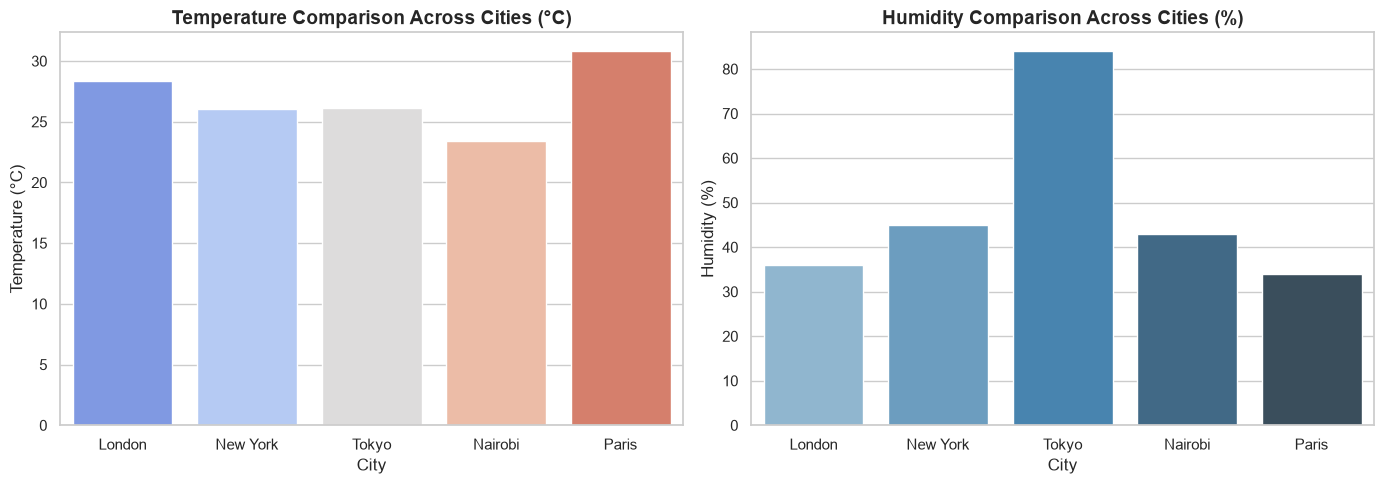


✅ Analysis complete and charts generated/saved successfully!


In [5]:
# ==========================================
# TASK 4: BASIC ANALYSIS & VISUALIZATION
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from the saved CSV file
df = pd.read_csv("weather_data.csv")

print("--- Weather Data Analysis Summary ---")

# 1. Compare temperatures across cities
hottest = df.loc[df["Temperature_C"].idxmax()]
coldest = df.loc[df["Temperature_C"].idxmin()]
avg_temp = df["Temperature_C"].mean()

print(f"\n[Temperature Comparison]")
print(f"• Hottest City: {hottest['City']} at {hottest['Temperature_C']}°C ({hottest['Weather_Condition']})")
print(f"• Coldest City: {coldest['City']} at {coldest['Temperature_C']}°C ({coldest['Weather_Condition']})")
print(f"• Average Temperature Across All Cities: {avg_temp:.2f}°C")

# 2. Identify the city with the highest humidity
highest_humidity_city = df.loc[df["Humidity_Percent"].idxmax()]
print(f"\n[Humidity Analysis]")
print(f"• City with Highest Humidity: {highest_humidity_city['City']} at {highest_humidity_city['Humidity_Percent']}%")

# 3. Compare weather conditions across cities
print(f"\n[Weather Conditions Comparison]")
for index, row in df.iterrows():
    print(f"• {row['City']}: {row['Weather_Condition']} | Temp: {row['Temperature_C']}°C | Humidity: {row['Humidity_Percent']}%")

# ==========================================
# GENERATE CHARTS
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature bar plot
sns.barplot(
    ax=axes[0],
    x="City",
    y="Temperature_C",
    data=df,
    palette="coolwarm"
)
axes[0].set_title("Temperature Comparison Across Cities (°C)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("City", fontsize=12)
axes[0].set_ylabel("Temperature (°C)", fontsize=12)

# Humidity bar plot
sns.barplot(
    ax=axes[1],
    x="City",
    y="Humidity_Percent",
    data=df,
    palette="Blues_d"
)
axes[1].set_title("Humidity Comparison Across Cities (%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("City", fontsize=12)
axes[1].set_ylabel("Humidity (%)", fontsize=12)

plt.tight_layout()
plt.savefig("weather_analysis_charts.png")
plt.show()
print("\n✅ Analysis complete and charts generated/saved successfully!")